## 7 - Loading Processed Data

In this step, we load processed video dataset from the previously notebook


In [26]:
import cv2
import glob
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import random
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
import urllib.request

In [27]:
print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_images/fplusplus_videos.csv"
videos = pd.read_csv(load_path)

print(f"{len(videos)} videos loaded!")
pd.set_option('display.max_colwidth', None)
display(videos.sample(15))

--- LOADING PROCESSED DATA ---
7000 videos loaded!


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution
6293,894_848.mp4,1,Face2Face,classic_894,classic_848,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/894_848.mp4,360,25.0,14.400000,1920x1080
6741,697_581.mp4,1,Face2Face,classic_697,classic_581,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/697_581.mp4,382,30.0,12.733333,1280x720
5317,310_196.mp4,1,NeuralTextures,classic_310,classic_196,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/310_196.mp4,375,25.0,15.000000,1280x720
322,01_04__talking_angry_couch__0XUW13RW.mp4,1,DeepFakeDetection,dfd_01,dfd_04,talking_angry_couch,0XUW13RW,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/01_04__talking_angry_couch__0XUW13RW.mp4,1465,24.0,61.041667,1920x1080
3713,538_493.mp4,1,FaceShifter,classic_538,classic_493,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/538_493.mp4,596,25.0,23.840000,854x480
308,26_06__walk_down_hall_angry__L5BVR5L9.mp4,1,DeepFakeDetection,dfd_26,dfd_06,walk_down_hall_angry,L5BVR5L9,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/26_06__walk_down_hall_angry__L5BVR5L9.mp4,360,24.0,15.000000,1920x1080
1628,040_997.mp4,1,Deepfakes,classic_040,classic_997,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/040_997.mp4,548,25.0,21.920000,1280x720
1708,857_909.mp4,1,Deepfakes,classic_857,classic_909,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/857_909.mp4,640,30.0,21.333333,640x480
466,07_26__walk_down_hall_angry__FGNGC2GT.mp4,1,DeepFakeDetection,dfd_07,dfd_26,walk_down_hall_angry,FGNGC2GT,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/07_26__walk_down_hall_angry__FGNGC2GT.mp4,543,24.0,22.625000,1920x1080
5448,104_126.mp4,1,NeuralTextures,classic_104,classic_126,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/104_126.mp4,328,30.0,10.933333,640x480


## 8 - Stratified Target-Based and Source-Based Data Split (70/15/15)

In this section, we divide the dataset into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets. To evaluate and **compare** model performance effectively, we implemented two distinct splitting strategies:

1. **Target-Based Split** 
2. **Source-Based Split**

For both approaches, we mathematically guaranteed zero data leakage between the Train and Test sets while maintaining a balanced (stratified) distribution of Real/Fake labels and alteration techniques.

In [28]:
def split(array):
    train_t, temp_t = train_test_split(array, test_size=0.30, random_state=42)
    val_t, test_t = train_test_split(temp_t, test_size=0.50, random_state=42)
    return set(train_t), set(val_t), set(test_t)

def assign_split(series, train_set, val_set, test_set):
    conditions = [
        series.isna(),    
        series.isin(train_set),
        series.isin(val_set),
        series.isin(test_set)
    ]
    
    choices = [
        'unknown',
        'train',
        'val',
        'test'
    ]

    return np.select(conditions, choices, default='unknown')

In [29]:
print("--- TARGET BASED SPLIT ---")

dfd_mask = videos['method'] == "DeepFakeDetection"

dfd_targest = videos[dfd_mask]['target'].dropna().unique()
classic_targets = videos[~dfd_mask]['target'].dropna().unique()

train_trg_dfd, val_trg_dfd, test_trg_dfd = split(dfd_targest)
train_trg_class, val_trg_class, test_trg_class = split(classic_targets)

train_trg_set = train_trg_dfd.union(train_trg_class)
val_trg_set = val_trg_dfd.union(val_trg_class)
test_trg_set = test_trg_dfd.union(test_trg_class)

videos['split_target_based'] = assign_split(videos['target'], train_trg_set, val_trg_set, test_trg_set)

display(videos.sample(10))

--- TARGET BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split_target_based
1790,693_698.mp4,1,Deepfakes,classic_693,classic_698,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/693_698.mp4,595,25.0,23.800000,656x480,train
3343,910_911.mp4,1,FaceShifter,classic_910,classic_911,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/910_911.mp4,292,30.0,9.733333,1280x720,train
1212,464_463.mp4,1,Deepfakes,classic_464,classic_463,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/464_463.mp4,404,25.0,16.160000,640x480,train
1483,798_778.mp4,1,Deepfakes,classic_798,classic_778,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/798_778.mp4,371,30.0,12.366667,1920x1080,train
5525,723_704.mp4,1,NeuralTextures,classic_723,classic_704,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/723_704.mp4,450,25.0,18.000000,832x480,train
1727,361_448.mp4,1,Deepfakes,classic_361,classic_448,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/361_448.mp4,455,30.0,15.166667,1280x720,train
3006,051_332.mp4,1,FaceShifter,classic_051,classic_332,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/051_332.mp4,717,25.0,28.680000,1280x720,train
420,14_20__hugging_happy__B014BKVO.mp4,1,DeepFakeDetection,dfd_14,dfd_20,hugging_happy,B014BKVO,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/14_20__hugging_happy__B014BKVO.mp4,110,24.0,4.583333,1920x1080,test
772,02_15__exit_phone_room__MZWH8ATN.mp4,1,DeepFakeDetection,dfd_02,dfd_15,exit_phone_room,MZWH8ATN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/02_15__exit_phone_room__MZWH8ATN.mp4,259,24.0,10.791667,1920x1080,val
4231,546_621.mp4,1,FaceSwap,classic_546,classic_621,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/546_621.mp4,370,30.0,12.333333,854x480,val


In [30]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split_target_based'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_trg_set.intersection(test_trg_set)
print(f"Targets shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split_target_based'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split_target_based'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split_target_based
train    68.86%
test     15.67%
val      15.47%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Targets shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split_target_based,,
test,13.7%,86.3%
train,14.5%,85.5%
val,13.9%,86.1%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split_target_based,,,,,,,
test,18.0%,13.7%,13.7%,13.7%,13.7%,13.7%,13.7%
train,12.9%,14.5%,14.5%,14.5%,14.5%,14.5%,14.5%
val,16.9%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%


In [31]:
print("--- SOURCE BASED SPLIT ---")

dfd_mask = videos['method'] == "DeepFakeDetection"
dfd_sources = videos[dfd_mask]['source'].dropna().unique()
classic_sources = videos[~dfd_mask]['source'].dropna().unique()

train_src_dfd, val_src_dfd, test_src_dfd = split(dfd_sources)
train_src_class, val_src_class, test_src_class = split(classic_sources)

train_src_set = train_src_dfd.union(train_src_class)
val_src_set = val_src_dfd.union(val_src_class)
test_src_set = test_src_dfd.union(test_src_class)

videos['split_source_based'] = assign_split(videos['source'], train_src_set, val_src_set, test_src_set)

display(videos.sample(10))

--- SOURCE BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split_target_based,split_source_based
3627,637_427.mp4,1,FaceShifter,classic_637,classic_427,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/637_427.mp4,510,60.0,8.500000,1280x720,train,train
616,02_15__outside_talking_pan_laughing__SB6PMCO0.mp4,1,DeepFakeDetection,dfd_02,dfd_15,outside_talking_pan_laughing,SB6PMCO0,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/02_15__outside_talking_pan_laughing__SB6PMCO0.mp4,627,24.0,26.125000,1920x1080,val,val
3254,138_142.mp4,1,FaceShifter,classic_138,classic_142,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/138_142.mp4,410,25.0,16.400000,600x480,test,test
4511,983_113.mp4,1,FaceSwap,classic_983,classic_113,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/983_113.mp4,406,25.0,16.240000,854x480,train,train
5276,480_389.mp4,1,NeuralTextures,classic_480,classic_389,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/480_389.mp4,314,25.0,12.560000,1280x720,train,train
3551,773_652.mp4,1,FaceShifter,classic_773,classic_652,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/773_652.mp4,579,30.0,19.300000,1280x720,train,train
2955,951.mp4,0,original,classic_951,classic_951,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/951.mp4,1176,30.0,39.200000,1280x720,val,val
537,03_11__walk_down_hall_angry__P08VGHTA.mp4,1,DeepFakeDetection,dfd_03,dfd_11,walk_down_hall_angry,P08VGHTA,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/03_11__walk_down_hall_angry__P08VGHTA.mp4,437,24.0,18.208333,1920x1080,train,test
153,06_12__outside_talking_pan_laughing__3K21NFNM.mp4,1,DeepFakeDetection,dfd_06,dfd_12,outside_talking_pan_laughing,3K21NFNM,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/06_12__outside_talking_pan_laughing__3K21NFNM.mp4,586,24.0,24.416667,1920x1080,train,train
5128,504_502.mp4,1,NeuralTextures,classic_504,classic_502,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/504_502.mp4,317,30.0,10.566667,1280x720,train,train


In [32]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split_source_based'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_src_set.intersection(test_src_set)
print(f"Sources shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split_source_based'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split_source_based'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split_source_based
train    69.46%
test     15.41%
val      15.13%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Sources shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split_source_based,,
test,13.9%,86.1%
train,14.4%,85.6%
val,14.2%,85.8%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split_source_based,,,,,,,
test,16.6%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%
train,13.6%,14.4%,14.4%,14.4%,14.4%,14.4%,14.4%
val,15.0%,14.2%,14.2%,14.2%,14.2%,14.2%,14.2%


## 9 - Frame Extraction & Preprocessing

To prepare the dataset and maximize temporal variance, we extract **5 equidistant frames** per video and process them through a targeted pipeline:

* **SSD Face Detection**: We use OpenCV's DNN (ResNet-10 SSD) to detect faces. Detections are cropped with a 15% margin and padded into a square to prevent aspect-ratio distortion.
* **Fallback Method:** If the model fails to confidently detect a face, we automatically apply a static center crop.
* **Standardization**: Every extracted face is resized to **224x224 pixels**, which is the standard input size for most modern vision backbones.

In [33]:
# CONFIGURATION
base_root = "F++_Split_Intra"
dir_src = "source_based"
dir_trg = "target_based"
fpv = 5
target_size = (224, 224)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

print(f"--- STARTING EXTRACTION: {fpv} FRAMES PER VIDEO ---")
print(f"--- PRIMARY METHOD: OpenCV DNN | FALLBACK: CENTER CROP ---")
print(f"--- TARGET SIZE: {target_size} ---")

# Download models
os.makedirs("models", exist_ok=True)
prototxt_path = "models/deploy.prototxt"
model_path = "models/res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists(prototxt_path):
    print("Downloading deploy.prototxt...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        prototxt_path
    )

if not os.path.exists(model_path):
    print("Downloading caffemodel (circa 10 MB)...")
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        model_path
    )

print("Models ready!")

# Load SSD (Face Detector)
net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Center Crop
def apply_static_center_crop(frame, target_size):
    h, w = frame.shape[:2]
    min_dim = min(h, w)
    start_x = (w - min_dim) // 2
    start_y = (h - min_dim) // 2
    crop_frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
    return cv2.resize(crop_frame, target_size, interpolation=cv2.INTER_AREA)

# Utility
def is_video_complete(video_name, folder_src, folder_trg, fpv_target):
    src_ok = True
    trg_ok = True
    
    if folder_src:
        if not os.path.exists(folder_src): return False
        frames_src = [f for f in os.listdir(folder_src) if f.startswith(f"{video_name}_f") and f.endswith('.jpg')]
        if len(frames_src) < fpv_target: src_ok = False
            
    if folder_trg:
        if not os.path.exists(folder_trg): return False
        frames_trg = [f for f in os.listdir(folder_trg) if f.startswith(f"{video_name}_f") and f.endswith('.jpg')]
        if len(frames_trg) < fpv_target: trg_ok = False
            
    return src_ok and trg_ok

# MAIN LOOP
for idx, row in tqdm(videos.iterrows(), total=len(videos)):
    video_path = row['path']
    split_src = row.get('split_source_based', 'unknown')
    split_trg = row.get('split_target_based', 'unknown')

    if split_src == 'unknown' and split_trg == 'unknown':
        continue

    label = "original" if row['label'] == 0 else "fake"
    video_name = f"{row['method']}_{os.path.splitext(row['video'])[0]}"

    folder_src = os.path.join(base_root, dir_src, split_src, label) if split_src != 'unknown' else None
    folder_trg = os.path.join(base_root, dir_trg, split_trg, label) if split_trg != 'unknown' else None

    # Checkpoint
    if is_video_complete(video_name, folder_src, folder_trg, fpv):
        continue

    if folder_src: os.makedirs(folder_src, exist_ok=True)
    if folder_trg: os.makedirs(folder_trg, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Errore: Impossibile aprire il video {video_path}")
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < fpv:
        cap.release()
        continue

    target_indices = np.linspace(0, total_frames - 1, fpv, endpoint=False, dtype=int)
    
    for extracted_count, target_idx in enumerate(target_indices):
        # Fast Seeking
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        
        # Save read fallaback
        if not ret:
            cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, target_idx - 5))
            ret, frame = cap.read()
            if not ret:
                continue 

        processed_frame = None
        save_suffix = ""

        # Face Detection via SSD
        (h, w) = frame.shape[:2]
        blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
        net.setInput(blob)
        detections = net.forward()

        if detections.shape[2] > 0:
            confidence = detections[0, 0, 0, 2]
            if confidence > 0.6:
                box = detections[0, 0, 0, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)
                
                w_b, h_b = x2 - x1, y2 - y1
                margin = int(max(w_b, h_b) * 0.15)
                cx1, cy1 = max(0, x1-margin), max(0, y1-margin)
                cx2, cy2 = min(w, x2+margin), min(h, y2+margin)
                
                crop_face = frame[cy1:cy2, cx1:cx2]
                if crop_face.size > 0:
                    fh, fw = crop_face.shape[:2]
                    side = max(fh, fw)
                    square = np.zeros((side, side, 3), np.uint8)
                    square[(side-fh)//2 : (side-fh)//2+fh, (side-fw)//2 : (side-fw)//2+fw] = crop_face
                    processed_frame = cv2.resize(square, target_size, interpolation=cv2.INTER_AREA)
                    save_suffix = "ssd"

        # Fallback if SSD fails
        if processed_frame is None:
            processed_frame = apply_static_center_crop(frame, target_size)
            save_suffix = "cc"

        # Saving process
        frame_filename = f"{video_name}_f{extracted_count}_{save_suffix}.jpg"
        
        for folder in [folder_src, folder_trg]:
            if folder:
                save_path = os.path.join(folder, frame_filename)
                cv2.imwrite(save_path, processed_frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

    cap.release()

print("\n--- EXTRACTION COMPLETE ---")
print(f"Data saved successfully under the '{base_root}/' directory.")

Running on device: cpu
--- STARTING EXTRACTION: 5 FRAMES PER VIDEO ---
--- PRIMARY METHOD: OpenCV DNN | FALLBACK: CENTER CROP ---
--- TARGET SIZE: (224, 224) ---
Models ready!


100%|██████████| 7000/7000 [1:02:39<00:00,  1.86it/s]


--- EXTRACTION COMPLETE ---
Data saved successfully under the 'F++_Split_Intra/' directory.


In [ ]:
base_root = "F++_Split_Intra"
csv_data = []

print("Scanning folders...")

pattern = os.path.join(base_root, "**", "*.jpg")

for file_path in glob.glob(pattern, recursive=True):
    # Standardize path for Unix/Colab (converts \ to /)
    clean_path = file_path.replace('\\', '/')
    
    parts = clean_path.split('/')
    
    if len(parts) >= 5:
        method = parts[1]      
        split = parts[2]       
        label_str = parts[3] 
        
        label_num = 0 if label_str == 'original' else 1
        dataset_name = 'FF++' 
        
        csv_data.append({
            'path': clean_path,
            'label': label_num,
            'split': split,
            'dataset': dataset_name,
            'method': method
        })

df_frames = pd.DataFrame(csv_data)

print("--- SCAN COMPLETED ---")
print(f"Total frames recorded: {len(df_frames)}")
df_frames.sample(10)

Scanning folders...
--- SCAN COMPLETED ---
Total frames recorded: 70000


,path,label,split,dataset,method
3936,F++_Split_Intra/target_based/test/fake/NeuralTextures_580_524_f1_ssd.jpg,1,test,FF++,target_based
11434,F++_Split_Intra/target_based/train/fake/NeuralTextures_779_794_f0_ssd.jpg,1,train,FF++,target_based
57826,F++_Split_Intra/source_based/train/fake/DeepFakeDetection_02_09__kitchen_pan__9TDCEK1Q_f3_ssd.jpg,1,train,FF++,source_based
7317,F++_Split_Intra/target_based/train/original/original_549_f1_ssd.jpg,0,train,FF++,target_based
45058,F++_Split_Intra/source_based/train/fake/FaceSwap_518_131_f2_ssd.jpg,1,train,FF++,source_based
7246,F++_Split_Intra/target_based/train/original/original_414_f1_ssd.jpg,0,train,FF++,target_based
59550,F++_Split_Intra/source_based/train/fake/Deepfakes_328_320_f3_ssd.jpg,1,train,FF++,source_based
23312,F++_Split_Intra/target_based/train/fake/DeepFakeDetection_19_24__outside_talking_still_laughing__59PN7WZ2_f3_ssd.jpg,1,train,FF++,target_based
10316,F++_Split_Intra/target_based/train/fake/FaceShifter_874_291_f1_ssd.jpg,1,train,FF++,target_based
17585,F++_Split_Intra/target_based/train/fake/FaceShifter_616_614_f3_ssd.jpg,1,train,FF++,target_based


## 10 - Visual Sanity Check 

This serves as a critical "sanity check" to verify that the frame extraction process completed successfully without generating corrupted or blank images

In [35]:
base_root = "F++_Split_Intra"

print("--- SANITY CHECK (CSV vs DISK) ---")

expected_src = len(df_frames[df_frames['method'] == 'source_based'])
expected_trg = len(df_frames[df_frames['method'] == 'target_based'])

def count_frames_and_methods(base_dir):
    if not os.path.exists(base_dir):
        return 0, 0, 0
    total, ssd, cc = 0, 0, 0
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.jpg') or file.endswith('.png'):
                total += 1
                if '_ssd' in file:
                    ssd += 1
                elif '_cc' in file:
                    cc += 1
    return total, ssd, cc

dir_src_path = os.path.join(base_root, "source_based")
dir_trg_path = os.path.join(base_root, "target_based")

actual_src, src_ssd, src_cc = count_frames_and_methods(dir_src_path)
actual_trg, trg_ssd, trg_cc = count_frames_and_methods(dir_trg_path)

def print_stats(name, expected, actual, ssd, cc):
    print(f"\n--- {name.upper()} STATISTICS ---")
    print(f"Frames in CSV (Expected):  {expected}")
    print(f"Frames on Disk (Found):    {actual}")
    
    if expected == actual and expected > 0:
        print("STATUS: PERFECT! CSV and Disk are perfectly synced.")
    elif actual == 0:
        print("STATUS: WARNING/INFO! No frames found in this directory.")
    else:
        print(f"STATUS: MISMATCH! Difference of {abs(expected - actual)} frames.")
        
    if actual > 0:
        print(f"  -> SSD Faces:     {ssd} ({(ssd/actual)*100:.1f}%)")
        print(f"  -> Center Crop:   {cc} ({(cc/actual)*100:.1f}%)")

print_stats("SOURCE_BASED", expected_src, actual_src, src_ssd, src_cc)
print_stats("TARGET_BASED", expected_trg, actual_trg, trg_ssd, trg_cc)

print(f"\nTotal frames in CSV across both splits: {expected_src + expected_trg}")
print(f"Total frames on disk across both splits:  {actual_src + actual_trg}")

--- SANITY CHECK (CSV vs DISK) ---

--- SOURCE_BASED STATISTICS ---
Frames in CSV (Expected):  35000
Frames on Disk (Found):    35000
STATUS: PERFECT! CSV and Disk are perfectly synced.
  -> SSD Faces:     34147 (97.6%)
  -> Center Crop:   853 (2.4%)

--- TARGET_BASED STATISTICS ---
Frames in CSV (Expected):  35000
Frames on Disk (Found):    35000
STATUS: PERFECT! CSV and Disk are perfectly synced.
  -> SSD Faces:     34147 (97.6%)
  -> Center Crop:   853 (2.4%)

Total frames in CSV across both splits: 70000
Total frames on disk across both splits:  70000



--- VISUALIZING RANDOM FRAMES FROM DATAFRAME ---


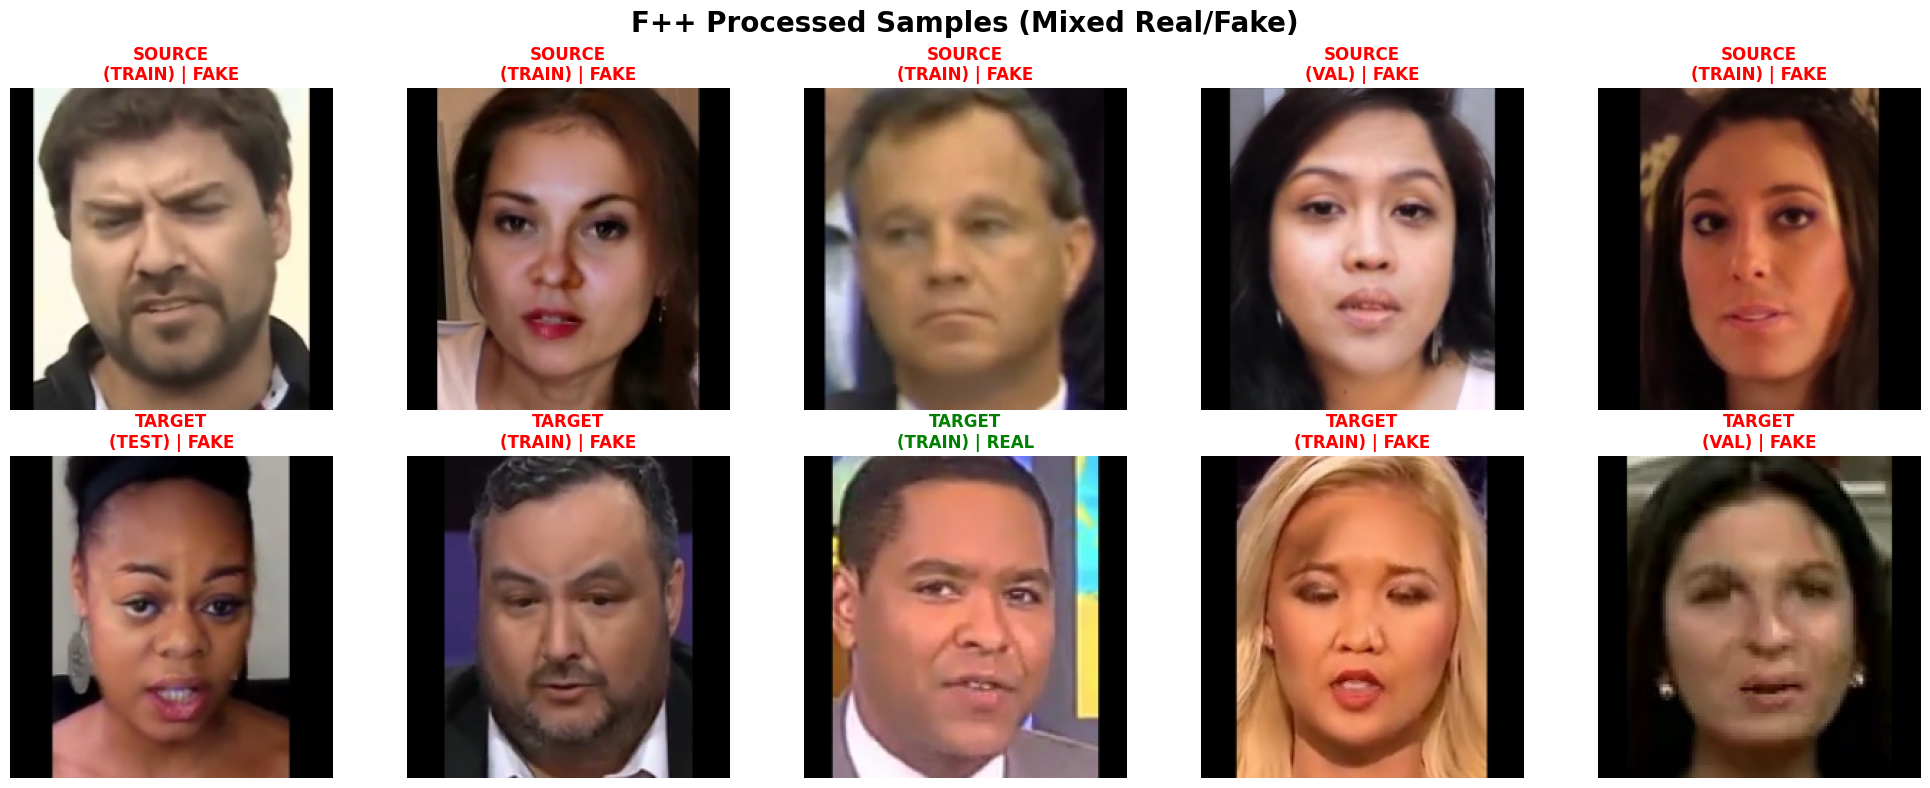

In [36]:
def show_both_splits_frames_from_df(dataframe, num_images=5):
    print("\n--- VISUALIZING RANDOM FRAMES FROM DATAFRAME ---")
    
    df_src = dataframe[dataframe['method'] == 'source_based']
    df_trg = dataframe[dataframe['method'] == 'target_based']
    
    sample_src = df_src.sample(n=min(num_images, len(df_src))).to_dict('records')
    sample_trg = df_trg.sample(n=min(num_images, len(df_trg))).to_dict('records')
    
    sample = sample_src + sample_trg
    
    if not sample:
        print("No images found in the DataFrame...")
        return 

    cols = 5
    rows = math.ceil(len(sample) / cols)
    
    plt.figure(figsize=(20, 4 * rows))
    plt.suptitle("F++ Processed Samples (Mixed Real/Fake)", fontsize=20, fontweight='bold')

    for i, row in enumerate(sample):
        plt.subplot(rows, cols, i+1)

        img_path = row['path']
        try:
            img = Image.open(img_path)
            plt.imshow(img)
        except Exception as e:
            print(f"Immagine non trovata o illeggibile: {img_path}")
            
        plt.axis('off')

        label = "REAL" if row['label'] == 0 else "FAKE"
        split_type = row['method'].split('_')[0].upper() 
        subset = row['split'].upper() 
        
        title_color = 'green' if label == "REAL" else 'red'
        plt.title(f"{split_type}\n({subset}) | {label}", color=title_color, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_both_splits_frames_from_df(df_frames, num_images=fpv)

## 11 - Saving Processed Data

To conclude this notebook, we save the fully cleaned and processed DataFrame to a local CSV file (`./processed_images/fplusplus_extracted_frames.csv`). This ensures our prepared dataset is safely stored and ready to be directly loaded into the next notebook of our pipeline without needing to re-run the preprocessing steps.

In [37]:
print("--- SAVING DATAFRAME ---")

output_dir = "./processed_images"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "fplusplus_extracted_frames.csv")
df_frames.to_csv(save_path, index=False)

print(f"Data succesfully saved to: {save_path}")

--- SAVING DATAFRAME ---
Data succesfully saved to: ./processed_images/fplusplus_extracted_frames.csv
